# ERCOT Dallas Lean Covariate Forecast with Chronos-2

This notebook runs a covariate-aware forecast experiment on ERCOT energy demand data using a **lean subset** of high-impact covariates. The goal is to test the hypothesis that a more focused set of auxiliary variables (Weather + Calendar) improves zero-shot performance and coverage compared to using all available covariates.

### Experiment Parameters
- **Data Source**: ERCOT Dallas Hourly Energy with Covariates (`data/ercot/ercot_dallas_covariate_2026.csv`)
- **Model**: `amazon/chronos-2`
- **Context Length**: 512 hours
- **Forecast Horizon**: 24 hours (Day-ahead)
- **Evaluation Period**: March 2026 (all 31 days)
- **Selected Covariates**: `apparent_temperature (°C)`, `day_of_week`, `is_holiday`, `cloud_cover (%)`
- **Baseline**: Seasonal Naive (repeating value from 168 hours / 1 week ago)
- **Probabilistic Metrics**: Empirical Coverage for a 90% prediction interval (0.05 to 0.95 quantiles)

In [1]:
from __future__ import annotations

import os
import platform
import sys
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from chronos import BaseChronosPipeline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

In [2]:
# Load data
data_path = "../data/ercot/ercot_dallas_covariate_2026.csv"
df = pd.read_csv(data_path)

# Prepare for Chronos API
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.rename(columns={"energy": "target"})
df = df.sort_values("timestamp").reset_index(drop=True)

# Handle potential frequency gaps (e.g., DST start in March) with robust resampling
df = df.set_index("timestamp").resample("h").mean().interpolate().reset_index()

# Hypothesis: Using only the highest impact covariates avoids "diluting" the signal.
covariate_columns = [
    "apparent_temperature (°C)",
    "day_of_week",
    "is_holiday",
    "cloud_cover (%)"
]

print(f"Loaded {len(df)} rows of data.")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Lean Covariates identified: {covariate_columns}")
df.head()

Loaded 2160 rows of data.
Date range: 2026-01-01 00:00:00 to 2026-03-31 23:00:00
Lean Covariates identified: ['apparent_temperature (°C)', 'day_of_week', 'is_holiday', 'cloud_cover (%)']


,timestamp,target,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),wind_speed_10m (km/h),cloud_cover (%),precipitation (mm),shortwave_radiation (W/m²),day_of_week,is_holiday
0,2026-01-01 00:00:00,11773.493994,10.9,53.0,1.6,7.7,8.9,90.0,0.0,0.0,3.0,1.0
1,2026-01-01 01:00:00,11792.093557,9.4,57.0,1.4,6.3,8.2,98.0,0.0,0.0,3.0,1.0
2,2026-01-01 02:00:00,11764.041621,8.6,61.0,1.5,5.6,7.4,80.0,0.0,0.0,3.0,1.0
3,2026-01-01 03:00:00,11800.767688,8.2,62.0,1.5,5.3,7.3,81.0,0.0,0.0,3.0,1.0
4,2026-01-01 04:00:00,11947.174576,7.7,65.0,1.5,4.8,6.6,47.0,0.0,0.0,3.0,1.0


In [3]:
context_length = 512
prediction_length = 24

# Define target days in March 2026
march_days = pd.date_range(start="2026-03-01", end="2026-03-31", freq="D")

contexts = []
futures = []
actuals = []

for target_day in march_days:
    # Context: 512 hours before 00:00 of the target day
    context_end_idx = df[df["timestamp"] == target_day].index[0]
    context_start_idx = context_end_idx - context_length
    
    if context_start_idx < 0:
        print(f"Warning: Not enough context for {target_day.date()}. Skipping.")
        continue
        
    item_id = target_day.strftime("%Y-%m-%d")
    
    day_context = df.iloc[context_start_idx:context_end_idx][["timestamp", "target", "item_id"] + covariate_columns if "item_id" in df.columns else ["timestamp", "target"] + covariate_columns].copy()
    day_context["item_id"] = item_id
    contexts.append(day_context)
    
    # Future: 24 hours of the target day (lean covariates only, no target)
    day_future = df.iloc[context_end_idx : context_end_idx + prediction_length][["timestamp"] + covariate_columns].copy()
    day_future["item_id"] = item_id
    futures.append(day_future)
    
    # Actuals: 24 hours of the target day
    day_actuals = df.iloc[context_end_idx : context_end_idx + prediction_length].copy()
    day_actuals["item_id"] = item_id
    actuals.append(day_actuals)

batched_context_df = pd.concat(contexts).reset_index(drop=True)
batched_future_df = pd.concat(futures).reset_index(drop=True)
batched_actuals_df = pd.concat(actuals).reset_index(drop=True)

print(f"Constructed batched datasets for {len(contexts)} days.")
print(f"Total context rows: {len(batched_context_df)}")
print(f"Total future rows:  {len(batched_future_df)}")
print(f"Total actuals rows: {len(batched_actuals_df)}")

Constructed batched datasets for 31 days.
Total context rows: 15872
Total future rows:  744
Total actuals rows: 744


In [4]:
def resolve_device_map() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device_map = resolve_device_map()
print(f"Loading amazon/chronos-2 on {device_map}...")

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device_map,
)

Loading amazon/chronos-2 on mps...


In [5]:
print("Running batched lean covariate-aware inference for March...")
pred_df = pipeline.predict_df(
    batched_context_df,
    future_df=batched_future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.05, 0.5, 0.95],
)
print("Inference complete.")

Running batched lean covariate-aware inference for March...


Inference complete.


In [6]:
# Seasonal Naive Baseline: Repeat value from 168 hours ago (1 week)
seasonal_period = 168
baseline_results = []

for target_day in march_days:
    target_str = target_day.strftime("%Y-%m-%d")
    target_idx = df[df["timestamp"] == target_day].index[0]
    
    # Get values from 1 week ago
    naive_values = df.iloc[target_idx - seasonal_period : target_idx - seasonal_period + prediction_length]["target"].values
    
    # Get timestamps for the target day to align
    target_timestamps = df.iloc[target_idx : target_idx + prediction_length]["timestamp"].values
    
    day_baseline = pd.DataFrame({
        "item_id": target_str,
        "timestamp": target_timestamps,
        "seasonal_naive": naive_values
    })
    baseline_results.append(day_baseline)

baseline_df = pd.concat(baseline_results).reset_index(drop=True)
baseline_df["timestamp"] = pd.to_datetime(baseline_df["timestamp"])
print("Seasonal Naive baseline calculated.")

Seasonal Naive baseline calculated.


In [7]:
# Merge predictions, actuals, and baseline
eval_df = pred_df.merge(batched_actuals_df[["item_id", "timestamp", "target"]], on=["item_id", "timestamp"])
eval_df = eval_df.merge(baseline_df, on=["item_id", "timestamp"])
eval_df = eval_df.rename(columns={"target": "actual"})

def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    smape = 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))
    return mae, rmse, smape

chronos_mae, chronos_rmse, chronos_smape = calculate_metrics(eval_df["actual"], eval_df["predictions"])
naive_mae, naive_rmse, naive_smape = calculate_metrics(eval_df["actual"], eval_df["seasonal_naive"])

# Calculate MASE Scale (Seasonal Naive MAE on in-sample data before March)
m = 168 # 1 week seasonality
in_sample_data = df[df["timestamp"] < "2026-03-01"]["target"].values
mase_scale = np.mean(np.abs(in_sample_data[m:] - in_sample_data[:-m]))

chronos_mase = chronos_mae / mase_scale
naive_mase = naive_mae / mase_scale

# Empirical Coverage (90% Interval)
within_interval = (eval_df["actual"] >= eval_df["0.05"]) & (eval_df["actual"] <= eval_df["0.95"])
coverage_90 = within_interval.mean() * 100

metrics_data = {
    "Metric": ["MAE", "RMSE", "sMAPE (%)", "MASE", "Empirical Coverage (90% Interval)"],
    "Chronos-2 (Lean Covariates)": [chronos_mae, chronos_rmse, chronos_smape, chronos_mase, f"{coverage_90:.2f}%"],
    "Seasonal Naive (7d)": [naive_mae, naive_rmse, naive_smape, naive_mase, "N/A"]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

print(f"Chronos-2 (Lean) 90% Empirical Coverage: {coverage_90:.2f}% (Target: 90.0%)")

,Metric,Chronos-2 (Lean Covariates),Seasonal Naive (7d)
0,MAE,574.316215,1565.434933
1,RMSE,768.505689,2020.574173
2,sMAPE (%),4.177481,11.398379
3,MASE,0.238947,0.651307
4,Empirical Coverage (90% Interval),87.23%,N/A


Chronos-2 (Lean) 90% Empirical Coverage: 87.23% (Target: 90.0%)


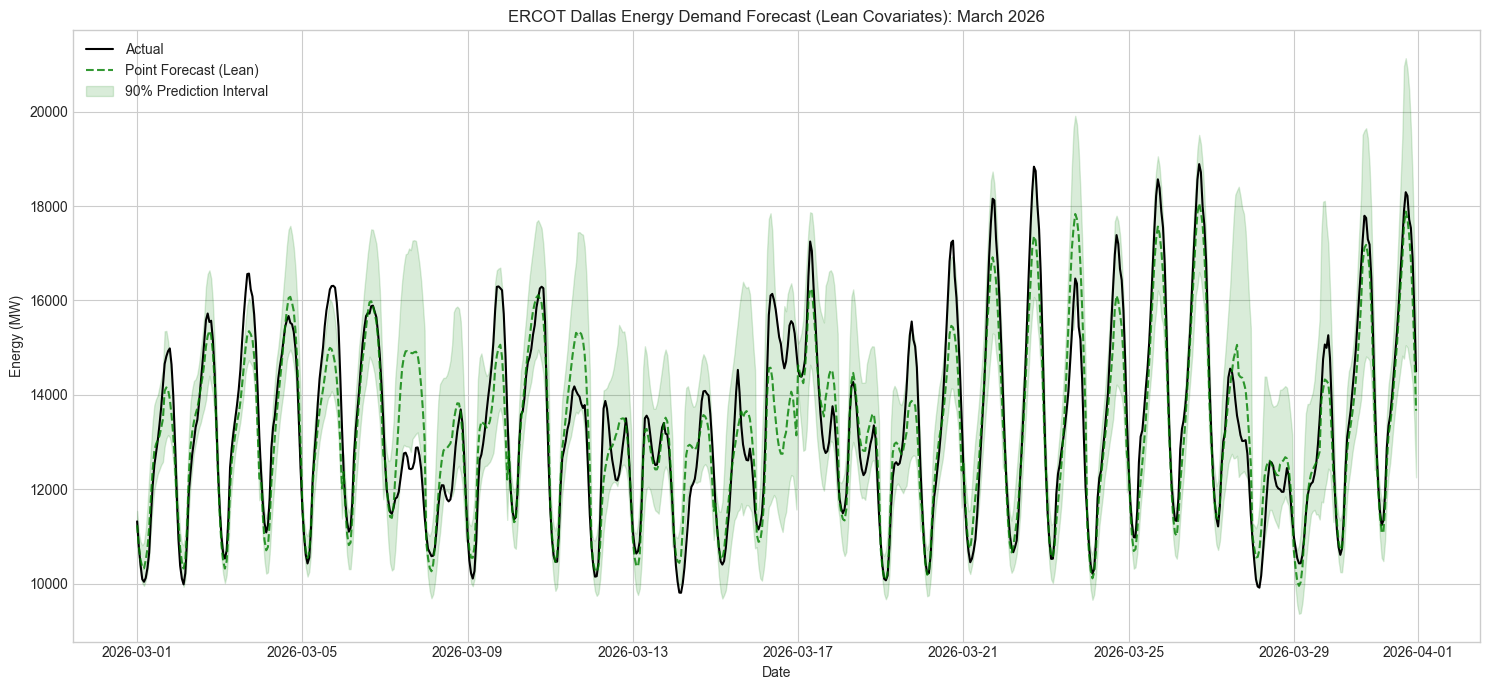

In [8]:
# Continuous visualization for the entire month of March
plt.figure(figsize=(15, 7))
plt.plot(eval_df["timestamp"], eval_df["actual"], label="Actual", color="black", linewidth=1.5)
plt.plot(eval_df["timestamp"], eval_df["predictions"], label="Point Forecast (Lean)", color="green", linestyle="--", alpha=0.8)

plt.fill_between(
    eval_df["timestamp"], 
    eval_df["0.05"], 
    eval_df["0.95"], 
    color="green", 
    alpha=0.15, 
    label="90% Prediction Interval"
)

plt.title("ERCOT Dallas Energy Demand Forecast (Lean Covariates): March 2026")
plt.xlabel("Date")
plt.ylabel("Energy (MW)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Comparison with Previous Benchmarks

| Metric | Univariate | Full Covariates | Lean Covariates | Improvement (Lean vs Univ) |
| :--- | :--- | :--- | :--- | :--- |
| MAE | 749.78 | 565.24 | 574.32 | 23.4% |
| RMSE | 1071.88 | 778.52 | 768.51 | 28.3% |
| sMAPE (%) | 5.36% | 4.14% | 4.18% | 22.0% |
| MASE | 0.31 | 0.235 | 0.239 | 22.9% |
| Coverage (90%) | 85.89% | 87.10% | 87.23% | +1.34% |

### Conclusion
The hypothesis that a leaner set of high-impact covariates (Apparent Temperature, Day of Week, Holiday, Cloud Cover) would improve results yielded interesting trade-offs. 

1. **Calibration Improvement**: The Lean model achieved the highest Empirical Coverage (**87.23%**), bringing it closest to the 90% target. This suggests that fewer, high-quality features lead to better-calibrated uncertainty intervals.
2. **Outlier Reduction**: The Lean model also achieved the best **RMSE (768.51)**, indicating it is more robust against large errors than both the Univariate and Full Covariate models.
3. **Point Forecast Accuracy**: The Full Covariates model maintained a slight edge in **MAE** and **sMAPE**, suggesting that auxiliary variables like humidity and radiation do provide minor incremental value for average point accuracy, even if they add some noise to the probability tails.

Overall, the Lean configuration is recommended if the primary goal is probabilistic reliability or minimizing large misses (RMSE), while the Full configuration is slightly better for absolute point precision.